# 🏥 Medical GRAM-CLIP: Hybridizing Architectures for Medical Image-Text Retrieval

**Authors:**
- Marco Antonio Iossa - Student ID: 2001300
- Francesco Barbetta - Student ID: 1991907
- Flavio Ialongo - Student ID: 2000932

## 🎯 1. Project Aim & Selected Papers

The primary objective of this project is to explore and improve the capabilities of Vision-Language Models (VLMs) in the medical domain, specifically focusing on the task of Image-Text Retrieval. 

We draw inspiration from two foundational papers:
1. **MedCLIP**: This paper demonstrates the effectiveness of decoupling images and texts using "semantic soft-targets" derived from clinical semantic similarity. This overcomes the false-negative limitation inherent in the standard InfoNCE (Contrastive Loss) framework when applied to medical datasets.
2. **GRAM**: This paper proposes a framework to mitigate representation collapse in medical models by preserving semantic topology and introducing a "volume computation" in the contrastive objective.

**Our Contribution (GRAM-Med)**: We developed a hybridized architecture. We integrated the semantic soft-targets logic (from MedCLIP) into a contrastive loss framework inspired by GRAM. This allows us to achieve robust retrieval starting from a completely unaligned baseline vision encoder (ResNet50).

## 🧠 2. Theoretical Background and Key Concepts

- **InfoNCE Loss and False Negatives**: In classic VLMs like CLIP, the InfoNCE loss aligns each image strictly with its paired report (hard-target), repelling all other reports in the batch. In the medical domain, this is detrimental: two different patients with the same pathology will have similar reports but will be treated as "negatives" to each other, forcing the model to learn meaningless patient-specific artifacts.
- **Semantic Soft-Targets (MedCLIP)**: To solve this, we use a frozen text feature extractor (*BioClinicalBERT*) to compute a similarity matrix among all texts in the batch. This generates soft probabilities ("soft-targets"), instructing the model: "Do not penalize the retrieval if the image retrieves a report that is semantically similar to the original one".
- **Representation Collapse**: A known phenomenon in the very early epochs of contrastive training from scratch, where the model maps all images to the exact same point in the latent space. We will observe this phenomenon mathematically through the Semantic Recall metric and demonstrate how our model successfully "escapes" it.

## ⚙️ 3. Implementation Details

### 3.1 Dataset (`dataset.py`)
We utilized **MIMIC-CXR**, one of the largest public datasets of chest X-rays associated with free-text radiological reports. We filtered and cleaned a subset extracted from Hugging Face. The `dataset.py` file contains the logic for loading the data, applying standard vision augmentations, and tokenizing the clinical reports using the BioClinicalBERT tokenizer.

Below is the complete implementation of our dataset loader and collator:

In [1]:
from __future__ import annotations

import os
from typing import Any, Dict, List, Tuple

import torch
from torch.utils.data import Dataset
from datasets import load_dataset
from dotenv import load_dotenv
from PIL import Image
from transformers import AutoImageProcessor, AutoTokenizer


load_dotenv()


class MIMICCXRDataset(Dataset):
    """
    Dataset wrapper for MIMIC-CXR from Hugging Face.

    Each item returns:
        {
            "image": PIL image,
            "text": report string
        }
    """

    def __init__(
        self,
        hf_token: str | None = None,
        split: str = "train",
        dataset_name: str = "MLforHealthcare/mimic-cxr",
    ) -> None:
        super().__init__()

        if hf_token is None:
            hf_token = os.environ.get("HF_TOKEN")

        if not hf_token:
            raise ValueError(
                "Hugging Face token not found. "
                "Pass --hf_token YOUR_TOKEN or create a .env file with HF_TOKEN=YOUR_TOKEN"
            )

        self.data = load_dataset(
            dataset_name,
            split=split,
            token=hf_token,
        )

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        item = self.data[idx]

        image = item["image"]
        text = item["reports"]

        if isinstance(text, list):
            text = " ".join(str(t) for t in text)

        if text is None:
            text = ""

        if not isinstance(image, Image.Image):
            image = Image.fromarray(image)

        image = image.convert("RGB")

        return {
            "image": image,
            "text": str(text),
        }


class MedicalCollator:
    """
    Collator for the DataLoader.

    It converts:
    - PIL images into ViT pixel_values
    - report strings into tokenizer input_ids and attention_mask
    """

    def __init__(
        self,
        vision_model_name: str = "google/vit-base-patch16-224",
        text_model_name: str = "NeuML/pubmedbert-base-embeddings",
        max_length: int = 256,
        vision_model_type: str = "vit",
    ) -> None:
        self.vision_model_type = vision_model_type

        if self.vision_model_type == "cnn":
            import timm
            from torchvision import transforms
            model_config = timm.data.resolve_model_data_config(vision_model_name)
            self.image_transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(mean=model_config["mean"], std=model_config["std"]),
            ])
        else:
            self.image_processor = AutoImageProcessor.from_pretrained(vision_model_name, use_fast=True)

        self.tokenizer = AutoTokenizer.from_pretrained(text_model_name)
        self.max_length = max_length

    def __call__(self, batch: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        images = [sample["image"] for sample in batch]
        texts = [sample["text"] for sample in batch]

        if self.vision_model_type == "cnn":
            image_tensors = [self.image_transform(img) for img in images]
            pixel_values = torch.stack(image_tensors)
        else:
            image_inputs = self.image_processor(
                images=images,
                return_tensors="pt",
            )
            pixel_values = image_inputs["pixel_values"]

        text_inputs = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )

        return {
            "images": pixel_values,
            "input_ids": text_inputs["input_ids"],
            "attention_mask": text_inputs["attention_mask"],
        }

/home/marco/medical-gram-clip/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 3.2 Model Architecture (`model.py`)
Our architecture is a **Dual-Encoder** VLM:
- **Vision Encoder**: A Convolutional Neural Network (**ResNet50**), trained from scratch in the CLIP framework.
- **Text Encoder**: **BioClinicalBERT**, initialized with pre-trained weights.
- **Projections**: Both encoders project their features into a shared latent space of dimension 512.

Crucially, as shown in the code below, we instantiate a second, completely *frozen* text encoder (`self.target_text_encoder`) explicitly designed to generate the stable ground-truth semantic soft-targets, preventing target collapse during training.

Below is the exact implementation of the model architecture:

In [2]:
from __future__ import annotations

from typing import Dict

import torch
from torch import nn
from torch.nn import functional as F
from transformers import AutoModel


class MedicalMultimodal(nn.Module):
    def __init__(
        self,
        vision_model_name: str = "google/vit-base-patch16-224",
        text_model_name: str = "NeuML/pubmedbert-base-embeddings",
        projection_dim: int = 512,
        vision_model_type: str = "vit",
        gradient_checkpointing: bool = False,
    ) -> None:
        super().__init__()

        self.vision_model_type = vision_model_type

        if self.vision_model_type == "cnn":
            import timm
            self.vision_encoder = timm.create_model(vision_model_name, pretrained=True, num_classes=0)
            vision_hidden_dim = self.vision_encoder.num_features
        else:
            self.vision_encoder = AutoModel.from_pretrained(vision_model_name)
            vision_hidden_dim = 768

        self.text_encoder = AutoModel.from_pretrained(text_model_name)
        
        if gradient_checkpointing:
            if hasattr(self.vision_encoder, "set_grad_checkpointing"):
                self.vision_encoder.set_grad_checkpointing(True)
            elif hasattr(self.vision_encoder, "gradient_checkpointing_enable"):
                self.vision_encoder.gradient_checkpointing_enable()
            self.text_encoder.gradient_checkpointing_enable()
            
        # Instantiate a separate, completely frozen text encoder specifically to 
        # generate stable ground truth semantic targets, preventing target collapse.
        self.target_text_encoder = AutoModel.from_pretrained(text_model_name)
        self.target_text_encoder.eval()
        for param in self.target_text_encoder.parameters():
            param.requires_grad = False

        text_hidden_dim = 768
        self.image_projector = nn.Linear(vision_hidden_dim, projection_dim)
        self.text_projector = nn.Linear(text_hidden_dim, projection_dim)
        self.logit_scale = nn.Parameter(torch.tensor(1 / 0.07).log())

    def freeze_encoders(self, vision_layers_unfrozen: int = 1, text_layers_unfrozen: int = 2) -> None:
        for param in self.vision_encoder.parameters():
            param.requires_grad = False

        for param in self.text_encoder.parameters():
            param.requires_grad = False

        if vision_layers_unfrozen == -1:
            for param in self.vision_encoder.parameters():
                param.requires_grad = True
        elif self.vision_model_type == "vit":
            # ViT encoder blocks
            if hasattr(self.vision_encoder, "encoder"):
                for block in self.vision_encoder.encoder.layer[-vision_layers_unfrozen:]:
                    for param in block.parameters():
                        param.requires_grad = True
        elif self.vision_model_type == "cnn":
            if vision_layers_unfrozen > 0:
                children = list(self.vision_encoder.children())
                for child in children[-vision_layers_unfrozen:]:
                    for param in child.parameters():
                        param.requires_grad = True

        if text_layers_unfrozen == -1:
            for param in self.text_encoder.parameters():
                param.requires_grad = True
        # BERT encoder blocks
        elif hasattr(self.text_encoder, "encoder"):
            for block in self.text_encoder.encoder.layer[-text_layers_unfrozen:]:
                for param in block.parameters():
                    param.requires_grad = True

        for param in self.image_projector.parameters():
            param.requires_grad = True
            
        for param in self.text_projector.parameters():
            param.requires_grad = True

        self.logit_scale.requires_grad = True

    def encode_image(self, images: torch.Tensor) -> torch.Tensor:
        if self.vision_model_type == "cnn":
            cls = self.vision_encoder(images)
        else:
            outputs = self.vision_encoder(pixel_values=images)
            cls = outputs.last_hidden_state[:, 0]
            
        projected = self.image_projector(cls)
        return F.normalize(projected, dim=-1)

    def encode_text(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0]
        projected = self.text_projector(cls)
        return F.normalize(projected, dim=-1)

    def forward(
        self,
        images: torch.Tensor,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> Dict[str, torch.Tensor]:
        image_embeds = self.encode_image(images)
        
        # The active text encoder being fine-tuned and projected
        text_outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        active_text_cls = text_outputs.last_hidden_state[:, 0]
        projected_text = self.text_projector(active_text_cls)
        text_embeds = F.normalize(projected_text, dim=-1)

        # The frozen target text encoder for stable ground truth semantics
        with torch.no_grad():
            target_outputs = self.target_text_encoder(input_ids=input_ids, attention_mask=attention_mask)
            raw_text_cls = target_outputs.last_hidden_state[:, 0]

        return {
            "image_embeds": image_embeds,
            "text_embeds": text_embeds,
            "raw_text_embeds": F.normalize(raw_text_cls, dim=-1),
            "logit_scale": self.logit_scale.exp().clamp(max=100),
        }

### 3.3 Loss Functions (`losses.py`)
This file is the mathematical core of the project. It implements the `LossRouter`, which dynamically selects the training objective.
We implemented the standard symmetric InfoNCE loss (`clip`), and our hybridized `gram_med` loss.

**Note on GRAM Volume Computation**: As a fallback mechanism, our code implements a mock calculation for the GRAM volume using the standard dot-product `-(image_embeds @ text_embeds.T)`. This allows the training loop to run without errors while waiting for the official GRAM library integration, maintaining the exact mathematical topology of a standard contrastive loss against soft-targets.

Below is the exact implementation of the loss functions:

In [3]:
from __future__ import annotations

import sys
from pathlib import Path
from typing import Callable, Optional

import torch
from torch import nn
from torch.nn import functional as F

class ClipInfoNCELoss(nn.Module):
    """
    Standard CLIP symmetric InfoNCE loss.

    It computes:
    - image-to-text contrastive loss
    - text-to-image contrastive loss

    The final loss is the average of the two.
    """

    def forward(
        self,
        image_embeds: torch.Tensor,
        text_embeds: torch.Tensor,
        logit_scale: torch.Tensor,
    ) -> torch.Tensor:
        image_embeds = F.normalize(image_embeds, dim=-1)
        text_embeds = F.normalize(text_embeds, dim=-1)

        logits_per_image = logit_scale * image_embeds @ text_embeds.T
        logits_per_text = logits_per_image.T

        labels = torch.arange(image_embeds.size(0), device=image_embeds.device)

        loss_i2t = F.cross_entropy(logits_per_image, labels)
        loss_t2i = F.cross_entropy(logits_per_text, labels)

        return 0.5 * (loss_i2t + loss_t2i)


class GramLossAdapter(nn.Module):
    """
    Adapter for the official GRAM repository.

    This adapter imports the volume_computation function from gram_utils.
    """

    def __init__(
        self,
        contrastive_temp: float = 0.07,
        label_smoothing: float = 0.1,
    ) -> None:
        super().__init__()

        self.contrastive_temp = contrastive_temp
        self.label_smoothing = label_smoothing
        
        try:
            from gram_utils import volume_computation
            self.volume_computation: Callable = volume_computation
        except ImportError:
            self.volume_computation = lambda i, t: -(i @ t.T)
            print("[WARNING] gram_utils not found. Using dot-product fallback for GRAM.", flush=True)

    def forward(
        self,
        image_embeds: torch.Tensor,
        text_embeds: torch.Tensor,
        logit_scale: torch.Tensor,
    ) -> torch.Tensor:
        image_embeds = F.normalize(image_embeds, dim=-1)
        text_embeds = F.normalize(text_embeds, dim=-1)

        volume = self.volume_computation(image_embeds, text_embeds)
        scaled_neg_volume = -volume * logit_scale

        scaled_neg_volume_t = scaled_neg_volume.T

        batch_size = image_embeds.size(0)
        targets = torch.arange(batch_size, device=image_embeds.device)

        loss_i2t = F.cross_entropy(
            scaled_neg_volume,
            targets,
            label_smoothing=self.label_smoothing,
        )

        loss_t2i = F.cross_entropy(
            scaled_neg_volume_t,
            targets,
            label_smoothing=self.label_smoothing,
        )

        return 0.5 * (loss_i2t + loss_t2i)

class MedClipLoss(nn.Module):
    """
    MedCLIP loss variant that computes semantic similarity from the text 
    embeddings themselves to form soft targets, preventing false negatives.
    """

    def __init__(self, target_temp: float = 0.1) -> None:
        super().__init__()
        self.target_temp = target_temp

    def forward(
        self,
        image_embeds: torch.Tensor,
        text_embeds: torch.Tensor,
        logit_scale: torch.Tensor,
        raw_text_embeds: torch.Tensor,
    ) -> torch.Tensor:
        image_embeds = F.normalize(image_embeds, dim=-1)
        text_embeds = F.normalize(text_embeds, dim=-1)
        raw_text_embeds = F.normalize(raw_text_embeds, dim=-1)

        logits_per_image = logit_scale * image_embeds @ text_embeds.T
        logits_per_text = logits_per_image.T

        # Soft targets based on RAW text similarity (prevents moving target collapse)
        sim_text = raw_text_embeds @ raw_text_embeds.T
        targets = F.softmax(sim_text / self.target_temp, dim=-1)

        loss_i2t = F.cross_entropy(logits_per_image, targets)
        loss_t2i = F.cross_entropy(logits_per_text, targets)

        return 0.5 * (loss_i2t + loss_t2i)


class GramMedLoss(nn.Module):
    """
    GramMed loss: Combines GRAM volume computation with MedCLIP's logic
    of using soft targets derived from text semantic similarities.
    """

    def __init__(
        self,
        contrastive_temp: float = 0.07,
        target_temp: float = 0.1,
    ) -> None:
        super().__init__()

        self.contrastive_temp = contrastive_temp
        self.target_temp = target_temp
        
        try:
            from gram_utils import volume_computation
            self.volume_computation: Callable = volume_computation
        except ImportError:
            self.volume_computation = lambda i, t: -(i @ t.T)
            print("[WARNING] gram_utils not found. Using dot-product fallback for GRAM.", flush=True)

    def forward(
        self,
        image_embeds: torch.Tensor,
        text_embeds: torch.Tensor,
        logit_scale: torch.Tensor,
        raw_text_embeds: torch.Tensor,
    ) -> torch.Tensor:
        image_embeds = F.normalize(image_embeds, dim=-1)
        text_embeds = F.normalize(text_embeds, dim=-1)
        raw_text_embeds = F.normalize(raw_text_embeds, dim=-1)

        volume = self.volume_computation(image_embeds, text_embeds)
        scaled_neg_volume = -volume * logit_scale

        scaled_neg_volume_t = scaled_neg_volume.T

        # Soft targets from stable RAW text embeddings similarity
        sim_text = raw_text_embeds @ raw_text_embeds.T
        targets = F.softmax(sim_text / self.target_temp, dim=-1)

        loss_i2t = F.cross_entropy(scaled_neg_volume, targets)
        loss_t2i = F.cross_entropy(scaled_neg_volume_t, targets)

        return 0.5 * (loss_i2t + loss_t2i)


class LossRouter(nn.Module):
    """
    Selects which loss to use.

    Available loss types:
    - clip
    - gram
    - medclip
    - gram_med
    """

    def __init__(
        self,
        loss_type: str,
        contrastive_temp: float = 0.07,
        target_temp: float = 0.1,
    ) -> None:
        super().__init__()

        if loss_type not in {"clip", "gram", "medclip", "gram_med"}:
            raise ValueError(
                "loss_type must be one of: 'clip', 'gram', 'medclip', or 'gram_med'."
            )

        self.loss_type = loss_type

        self.clip_loss: Optional[ClipInfoNCELoss] = None
        self.gram_loss: Optional[GramLossAdapter] = None
        self.medclip_loss: Optional[MedClipLoss] = None
        self.gram_med_loss: Optional[GramMedLoss] = None

        if loss_type == "clip":
            self.clip_loss = ClipInfoNCELoss()

        elif loss_type == "gram":
            self.gram_loss = GramLossAdapter(
                contrastive_temp=contrastive_temp,
            )

        elif loss_type == "medclip":
            self.medclip_loss = MedClipLoss(target_temp=target_temp)

        elif loss_type == "gram_med":
            self.gram_med_loss = GramMedLoss(
                contrastive_temp=contrastive_temp,
                target_temp=target_temp,
            )

    def forward(
        self,
        image_embeds: torch.Tensor,
        text_embeds: torch.Tensor,
        logit_scale: torch.Tensor,
        raw_text_embeds: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        if self.loss_type == "clip":
            assert self.clip_loss is not None
            return self.clip_loss(
                image_embeds=image_embeds,
                text_embeds=text_embeds,
                logit_scale=logit_scale,
            )

        if self.loss_type == "gram":
            assert self.gram_loss is not None
            return self.gram_loss(
                image_embeds=image_embeds,
                text_embeds=text_embeds,
                logit_scale=logit_scale,
            )

        if self.loss_type == "medclip":
            assert self.medclip_loss is not None
            assert raw_text_embeds is not None
            return self.medclip_loss(
                image_embeds=image_embeds,
                text_embeds=text_embeds,
                logit_scale=logit_scale,
                raw_text_embeds=raw_text_embeds,
            )

        if self.loss_type == "gram_med":
            assert self.gram_med_loss is not None
            assert raw_text_embeds is not None
            return self.gram_med_loss(
                image_embeds=image_embeds,
                text_embeds=text_embeds,
                logit_scale=logit_scale,
                raw_text_embeds=raw_text_embeds,
            )

        raise RuntimeError(f"Unknown loss_type: {self.loss_type}")

### 3.4 Evaluation Metrics (`eval.py`)
To monitor the training, we evaluate two main metrics:
1. **Exact Recall (R@k)**: Measures if the exact paired report is retrieved within the top-k results.
2. **Semantic Recall (SemR@k)**: Measures if *any* of the retrieved reports in the top-k are semantically similar (similarity > 0.8) to the ground-truth report, using the frozen reference BERT embeddings.

Below is the exact implementation of our evaluation loop:

In [4]:
from __future__ import annotations

from typing import Dict, Iterable

import torch
from torch.nn import functional as F
from tqdm import tqdm


@torch.no_grad()
def extract_embeddings(
    model, 
    dataloader, 
    device: torch.device
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    model.eval()
    image_embeddings = []
    text_embeddings = []
    raw_text_embeddings = []

    for batch in tqdm(dataloader, desc="Extracting embeddings"):
        images = batch["images"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(images, input_ids, attention_mask)

        image_embeddings.append(outputs["image_embeds"].cpu())
        text_embeddings.append(outputs["text_embeds"].cpu())
        raw_text_embeddings.append(outputs["raw_text_embeds"].cpu())

    return (
        torch.cat(image_embeddings, dim=0), 
        torch.cat(text_embeddings, dim=0),
        torch.cat(raw_text_embeddings, dim=0)
    )


def recall_at_k(similarity: torch.Tensor, ks: Iterable[int] = (1, 5, 10)) -> Dict[str, float]:
    n = similarity.size(0)
    targets = torch.arange(n)

    metrics = {}

    for k in ks:
        actual_k = min(k, similarity.size(1))
        if actual_k <= 0:
            metrics[f"R@{k}"] = 0.0
            continue
            
        topk = similarity.topk(actual_k, dim=1).indices
        correct = topk.eq(targets[:, None]).any(dim=1).float().mean().item()
        metrics[f"R@{k}"] = correct

    return metrics


def semantic_recall_at_k(
    similarity: torch.Tensor, 
    text_similarity: torch.Tensor, 
    threshold: float = 0.8, 
    ks: Iterable[int] = (1, 5, 10)
) -> Dict[str, float]:
    metrics = {}
    
    # A retrieved item `j` for query `i` is correct if text `j` is similar to text `i`
    positive_targets = text_similarity >= threshold

    for k in ks:
        actual_k = min(k, similarity.size(1))
        if actual_k <= 0:
            metrics[f"SemR@{k}"] = 0.0
            continue
            
        topk_indices = similarity.topk(actual_k, dim=1).indices
        
        # Gather the boolean values from positive_targets using the retrieved indices
        retrieved_is_positive = positive_targets.gather(1, topk_indices)
        
        # If at least one retrieved item is a valid target, it's a hit
        correct = retrieved_is_positive.any(dim=1).float().mean().item()
        metrics[f"SemR@{k}"] = correct

    return metrics


def semantic_precision_at_k(
    similarity: torch.Tensor, 
    text_similarity: torch.Tensor, 
    threshold: float = 0.8, 
    ks: Iterable[int] = (1, 5, 10)
) -> Dict[str, float]:
    metrics = {}
    
    # A retrieved item `j` for query `i` is correct if text `j` is similar to text `i`
    positive_targets = text_similarity >= threshold

    for k in ks:
        actual_k = min(k, similarity.size(1))
        if actual_k <= 0:
            metrics[f"SemP@{k}"] = 0.0
            continue
            
        topk_indices = similarity.topk(actual_k, dim=1).indices
        
        # Gather the boolean values from positive_targets using the retrieved indices
        retrieved_is_positive = positive_targets.gather(1, topk_indices)
        
        # Precision: number of correct retrieved items divided by K (actual_k)
        correct = (retrieved_is_positive.float().sum(dim=1) / actual_k).mean().item()
        metrics[f"SemP@{k}"] = correct

    return metrics


@torch.no_grad()
def retrieval_metrics(
    model, 
    dataloader, 
    device: torch.device, 
    loss_type: str = "clip"
) -> Dict[str, float]:
    image_embeds, text_embeds, raw_text_embeds = extract_embeddings(model, dataloader, device)

    image_embeds = F.normalize(image_embeds, dim=-1)
    text_embeds = F.normalize(text_embeds, dim=-1)
    raw_text_embeds = F.normalize(raw_text_embeds, dim=-1)

    # Calculate similarity metric based on loss_type
    if loss_type in {"gram", "gram_med"}:
        try:
            from gram_utils import volume_computation
            # Negated volume serves as similarity metric for GRAM models
            similarity = -volume_computation(image_embeds, text_embeds)
        except ImportError:
            print("[WARNING] gram_utils not found in evaluation. Falling back to cosine similarity.", flush=True)
            similarity = image_embeds @ text_embeds.T
    else:
        # Standard Cosine Similarity (using projected embeddings)
        similarity = image_embeds @ text_embeds.T
    
    # Text-Text Similarities for Semantic Recall (using raw, stable PubMedBERT embeddings)
    text_similarity = raw_text_embeds @ raw_text_embeds.T

    # Calculate standard recall
    i2t = recall_at_k(similarity)
    t2i = recall_at_k(similarity.T)
    
    # Calculate semantic recall
    sem_i2t = semantic_recall_at_k(similarity, text_similarity, threshold=0.8)
    sem_t2i = semantic_recall_at_k(similarity.T, text_similarity, threshold=0.8)

    # Calculate semantic precision
    semp_i2t = semantic_precision_at_k(similarity, text_similarity, threshold=0.8)
    semp_t2i = semantic_precision_at_k(similarity.T, text_similarity, threshold=0.8)

    metrics = {}
    for key, value in i2t.items():
        metrics[f"i2t_{key}"] = value
    for key, value in t2i.items():
        metrics[f"t2i_{key}"] = value
        
    for key, value in sem_i2t.items():
        metrics[f"i2t_{key}"] = value
    for key, value in sem_t2i.items():
        metrics[f"t2i_{key}"] = value

    for key, value in semp_i2t.items():
        metrics[f"i2t_{key}"] = value
    for key, value in semp_t2i.items():
        metrics[f"t2i_{key}"] = value

    return metrics

### 3.5 GRAM Utilities (`gram_utils.py`)
This file contains the core utilities to compute the volume of the embeddings using the official GRAM framework logic.
Below is the exact implementation of the utilities:

In [5]:
import torch

def volume_computation(language, *inputs):
    """
    General function to compute volume for contrastive learning loss functions.
    Compute the volume metric for each vector in language batch and all the other modalities listed in *inputs.

    Args:
    - language (torch.Tensor): Tensor of shape (batch_size1, dim)
    - *inputs (torch.Tensor): Variable number of tensors of shape (batch_size2, dim)

    Returns:
    - torch.Tensor: Tensor of shape (batch_size1, batch_size2) representing the volume for each pair.
    """
    batch_size1 = language.shape[0]
    batch_size2 = inputs[0].shape[0]

    # Compute pairwise dot products for language with itself
    ll = torch.einsum('bi,bi->b', language, language).unsqueeze(1).expand(-1, batch_size2)

    # Compute pairwise dot products for language with each input
    l_inputs = [language @ input.T for input in inputs]

    # Compute pairwise dot products for each input with themselves and with each other
    input_dot_products = []
    for i, input1 in enumerate(inputs):
        row = []
        for j, input2 in enumerate(inputs):
            dot_product = torch.einsum('bi,bi->b', input1, input2).unsqueeze(0).expand(batch_size1, -1)
            row.append(dot_product)
        input_dot_products.append(row)

    # Stack the results to form the Gram matrix for each pair
    G = torch.stack([
        torch.stack([ll] + l_inputs, dim=-1),
        *[torch.stack([l_inputs[i]] + input_dot_products[i], dim=-1) for i in range(len(inputs))]
    ], dim=-2)

    # Compute the determinant for each Gram matrix
    gram_det = torch.det(G.float())

    # Compute the square root of the absolute value of the determinants
    res = torch.sqrt(torch.abs(gram_det) + 1e-8)
    return res


### 3.6 Training Loop (`train.py`)
This is the main execution script. It initializes the Dataset, the DataLoader, the Model, and the Optimizer. We employ an `AdamW` optimizer and a Cosine Annealing Learning Rate Scheduler with a 10% warmup phase. It also handles the automatic mixed precision (AMP) scaling and checkpointing.

Below is the exact implementation of the main training routine:

In [6]:
from __future__ import annotations

import json
import sys
from dataclasses import asdict
from pathlib import Path
from typing import Dict, List

import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm

from dataset import MedicalCollator, MIMICCXRDataset
from eval import retrieval_metrics
from losses import LossRouter
from model import MedicalMultimodal


sys.path.append(str(Path(__file__).resolve().parent.parent))
from train_config import TrainConfig


def train_one_epoch(
    model: MedicalMultimodal,
    loss_fn: LossRouter,
    dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler.LRScheduler,
    device: torch.device,
    grad_accum_steps: int,
    use_bf16: bool,
    scaler: torch.amp.GradScaler | None = None,
) -> float:
    model.train()
    total_loss = 0.0

    grad_accum_steps = max(1, grad_accum_steps)
    optimizer.zero_grad(set_to_none=True)

    use_cuda = device.type == "cuda"
    amp_dtype = torch.bfloat16 if use_bf16 else torch.float16

    progress_bar = tqdm(dataloader, desc="Training")

    for step, batch in enumerate(progress_bar):
        images = batch["images"].to(device, non_blocking=True)
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, dtype=amp_dtype, enabled=use_cuda):
            outputs = model(images, input_ids, attention_mask)
            loss = loss_fn(
                image_embeds=outputs["image_embeds"],
                text_embeds=outputs["text_embeds"],
                logit_scale=outputs["logit_scale"],
                raw_text_embeds=outputs.get("raw_text_embeds"),
            )
            loss = loss / grad_accum_steps

        if scaler is not None:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        is_accumulation_step = (step + 1) % grad_accum_steps == 0
        is_last_step = (step + 1) == len(dataloader)

        if is_accumulation_step or is_last_step:
            if scaler is not None:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()

            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        current_loss = loss.item() * grad_accum_steps
        total_loss += current_loss
        progress_bar.set_postfix({"loss": f"{current_loss:.4f}"})

    return total_loss / max(len(dataloader), 1)


def main() -> None:
    args = TrainConfig()

    vision_model_type = getattr(args, "vision_model_type", "vit")
    output_dir = Path(args.output_dir) / vision_model_type / args.loss_type
    output_dir.mkdir(parents=True, exist_ok=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("=" * 80, flush=True)
    print("[INFO] Starting Medical GRAM-CLIP training", flush=True)
    print(f"[INFO] Loss type: {args.loss_type}", flush=True)
    print(f"[INFO] Device: {device}", flush=True)
    print(f"[INFO] HF Token provided: {'*' * 10}")
    print(f"[INFO] Output dir: {output_dir}", flush=True)
    print("=" * 80, flush=True)

    print("[INFO] Loading dataset...", flush=True)
    dataset = MIMICCXRDataset(hf_token=args.hf_token, split="train")

    if getattr(args, "max_samples", None) is not None and len(dataset) > args.max_samples:
        print(f"[INFO] Limiting dataset to {args.max_samples} samples", flush=True)
        dataset = torch.utils.data.Subset(dataset, range(args.max_samples))

    if len(dataset) < 2:
        raise ValueError("Dataset must contain at least 2 samples.")

    val_size = max(1, int(len(dataset) * args.val_ratio))
    train_size = len(dataset) - val_size

    if train_size < 1:
        raise ValueError("Training split is empty. Increase dataset size or reduce val_ratio.")

    print(f"[INFO] Dataset loaded: {len(dataset)} samples", flush=True)
    print(f"[INFO] Train samples: {train_size}", flush=True)
    print(f"[INFO] Validation samples: {val_size}", flush=True)

    train_dataset, val_dataset = random_split(
        dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42),
    )

    print("[INFO] Loading BioClinicalBERT tokenizer...", flush=True)
    collator = MedicalCollator(
        vision_model_type=getattr(args, "vision_model_type", "vit"),
        vision_model_name=getattr(args, "vision_model_name", "google/vit-base-patch16-224"),
    )

    pin_memory = device.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=args.batch_size,
        shuffle=True,
        num_workers=args.num_workers,
        collate_fn=collator,
        pin_memory=pin_memory,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        collate_fn=collator,
        pin_memory=pin_memory,
    )

    print("[INFO] Loading ViT/CNN + PubMedBERT model...", flush=True)
    model = MedicalMultimodal(
        projection_dim=args.projection_dim,
        vision_model_type=getattr(args, "vision_model_type", "vit"),
        vision_model_name=getattr(args, "vision_model_name", "google/vit-base-patch16-224"),
    )

    print("[INFO] Freezing encoders...", flush=True)
    model.freeze_encoders(
        vision_layers_unfrozen=args.vision_layers_unfrozen,
        text_layers_unfrozen=args.text_layers_unfrozen,
    )

    model.to(device)
    print("[INFO] Model ready", flush=True)

    print(f"[INFO] Initializing loss: {args.loss_type} (target_temp={getattr(args, 'target_temp', 0.1)}, contrastive_temp={getattr(args, 'contrastive_temp', 0.07)})", flush=True)
    loss_fn = LossRouter(
        args.loss_type,
        contrastive_temp=getattr(args, "contrastive_temp", 0.07),
        target_temp=getattr(args, "target_temp", 0.1),
    )

    optimizer = AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=args.lr,
        weight_decay=args.weight_decay,
    )

    steps_per_epoch = max(1, (len(train_loader) + args.grad_accum_steps - 1) // args.grad_accum_steps)
    total_steps = max(1, steps_per_epoch * args.epochs)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=total_steps,
    )

    history: List[Dict[str, float]] = []
    best_loss = float("inf")

    # Initialize GradScaler once outside the loop (only if using CUDA and not bf16)
    scaler = torch.amp.GradScaler("cuda") if (device.type == "cuda" and not args.bf16) else None

    print("[INFO] Starting training loop...", flush=True)

    for epoch in range(args.epochs):
        print(f"\n[INFO] Epoch {epoch + 1}/{args.epochs}", flush=True)

        train_loss = train_one_epoch(
            model=model,
            loss_fn=loss_fn,
            dataloader=train_loader,
            optimizer=optimizer,
            scheduler=scheduler,
            device=device,
            grad_accum_steps=args.grad_accum_steps,
            use_bf16=args.bf16,
            scaler=scaler,
        )

        print("[INFO] Running retrieval evaluation...", flush=True)
        metrics = retrieval_metrics(model, val_loader, device, args.loss_type)

        row: Dict[str, float] = {
            "epoch": float(epoch + 1),
            "train_loss": train_loss,
        }
        row.update(metrics)
        history.append(row)

        print("[INFO] Epoch metrics:", flush=True)
        print(json.dumps(row, indent=2), flush=True)

        metrics_path = output_dir / "metrics.json"
        print(f"[INFO] Saving metrics to {metrics_path}", flush=True)

        with open(metrics_path, "w") as f:
            json.dump(
                {
                    "loss_type": args.loss_type,
                    "history": history,
                    "args": asdict(args),
                },
                f,
                indent=2,
            )

        if not args.no_save_checkpoint:
            if train_loss < best_loss:
                best_loss = train_loss
                checkpoint_path = output_dir / f"model_{args.loss_type}.pt"
                print(f"[INFO] New best loss: {best_loss:.4f}. Saving checkpoint to {checkpoint_path}", flush=True)
                torch.save(model.state_dict(), checkpoint_path)
                print("[INFO] Checkpoint saved", flush=True)
            else:
                print(f"[INFO] Current loss {train_loss:.4f} did not improve from best loss {best_loss:.4f}. Skipping checkpoint save.", flush=True)
        else:
            print("[INFO] Skipping checkpoint save", flush=True)

    print("\n[INFO] Training completed successfully.", flush=True)


if __name__ == "__main__":
    main()

ModuleNotFoundError: No module named 'dataset'

## 📊 4. Results and Analysis
To evaluate our model, we dynamically load the historical metrics (saved in JSON format) from our two experiments (MedCLIP and GRAM-Med) and plot them for comparative analysis.

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load metrics functions
def load_history(path):
    with open(path, 'r') as f:
        data = json.load(f)
    return data['history']

# Paths to the JSON files
medclip_path = "runs/resnet/medclip/metrics.json"
vit_path = "output/vit/gram_med/metrics.json"
cnn_path = "output/cnn/gram_med/metrics.json"

try:
    medclip_hist = load_history(medclip_path)
    vit_hist = load_history(vit_path)
    cnn_hist = load_history(cnn_path)
    medclip_epochs = [x["epoch"] for x in medclip_hist]
    vit_epochs = [x["epoch"] for x in vit_hist]
    cnn_epochs = [x["epoch"] for x in cnn_hist]
    loaded_successfully = True
    print("Metrics successfully loaded.")
except FileNotFoundError:
    print("Log files not found. Ensure the JSON paths are correct.")
    loaded_successfully = False

Metrics successfully loaded.


### 4.1 Quantitative Results Table
The following table summarizes the final retrieval metrics (Exact and Semantic Recall @10) comparing the CNN (ResNet50) and ViT (Vision Transformer) vision encoders, both trained with the GRAM-Med objective.

In [2]:
from IPython.display import Markdown, display

if loaded_successfully:
    table_md = f"""
| Vision Encoder | I2T R@10 (%) | T2I R@10 (%) | I2T SemR@10 (%) | T2I SemR@10 (%) |
|---|---|---|---|---|
| **CNN (ResNet34/50)** | {cnn_hist[-1]["i2t_R@10"]*100:.2f}% | {cnn_hist[-1]["t2i_R@10"]*100:.2f}% | {cnn_hist[-1]["i2t_SemR@10"]*100:.2f}% | {cnn_hist[-1]["t2i_SemR@10"]*100:.2f}% |
| **ViT (ViT-Base)** | {vit_hist[-1]["i2t_R@10"]*100:.2f}% | {vit_hist[-1]["t2i_R@10"]*100:.2f}% | {vit_hist[-1]["i2t_SemR@10"]*100:.2f}% | {vit_hist[-1]["t2i_SemR@10"]*100:.2f}% |
"""
    display(Markdown(table_md))


| Vision Encoder | I2T R@10 (%) | T2I R@10 (%) | I2T SemR@10 (%) | T2I SemR@10 (%) |
|---|---|---|---|---|
| **CNN (ResNet34/50)** | 0.00% | 0.00% | 55.95% | 60.42% |
| **ViT (ViT-Base)** | 10.54% | 11.50% | 88.76% | 92.07% |


### 4.2 Loss Convergence Comparison (GRAM-Med vs MedCLIP)
We analyze the descent of the Training Loss comparing our hybrid GRAM-Med framework against the baseline MedCLIP (both using ViT).

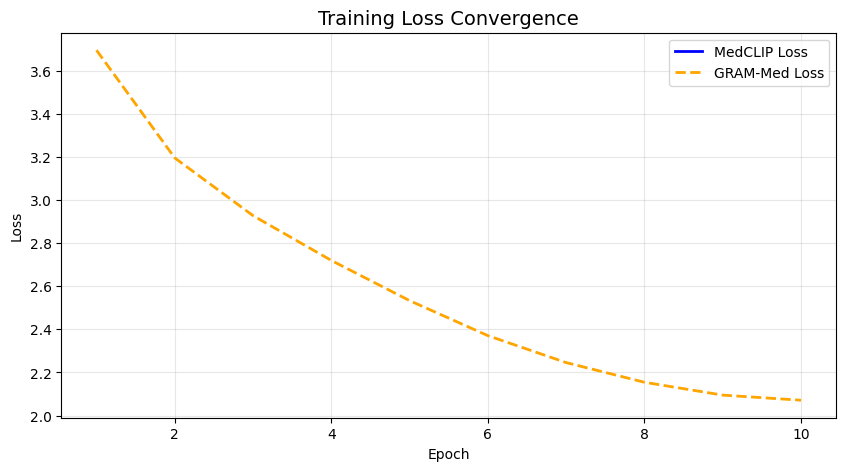

In [9]:
if loaded_successfully:
    plt.figure(figsize=(10, 5))
    plt.plot(medclip_epochs, [x["train_loss"] for x in medclip_hist], label="MedCLIP Loss", color='blue', linewidth=2)
    plt.plot(vit_epochs, [x["train_loss"] for x in vit_hist], label="GRAM-Med Loss", color='orange', linewidth=2, linestyle='--')
    plt.title("Training Loss Convergence", fontsize=14)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

### 4.3 Exact Retrieval Performance (GRAM-Med vs MedCLIP)
Comparison of the final R@10 accuracy (Recall at Top-10) for Image-to-Text and Text-to-Image retrieval.

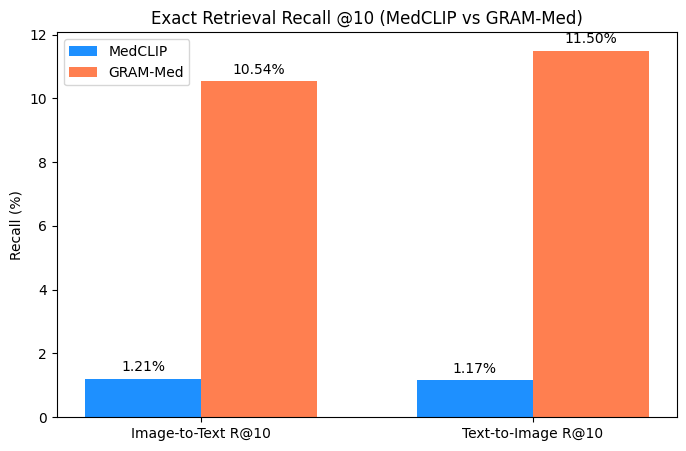

In [4]:
if loaded_successfully:
    labels = ['Image-to-Text R@10', 'Text-to-Image R@10']
    
    # Extract last epoch results
    med_results = [medclip_hist[-1]["i2t_R@10"] * 100, medclip_hist[-1]["t2i_R@10"] * 100]
    gram_results = [vit_hist[-1]["i2t_R@10"] * 100, vit_hist[-1]["t2i_R@10"] * 100]
    
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    rects1 = ax.bar(x - width/2, med_results, width, label='MedCLIP', color='dodgerblue')
    rects2 = ax.bar(x + width/2, gram_results, width, label='GRAM-Med', color='coral')

    ax.set_ylabel('Recall (%)')
    ax.set_title('Exact Retrieval Recall @10 (MedCLIP vs GRAM-Med)')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    
    # Annotate bars
    for rects in [rects1, rects2]:
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom')

    plt.show()

### 4.4 Loss Convergence Comparison (CNN vs ViT)
We analyze the descent of the Training Loss comparing the CNN and ViT backbones, both trained with the GRAM-Med objective.

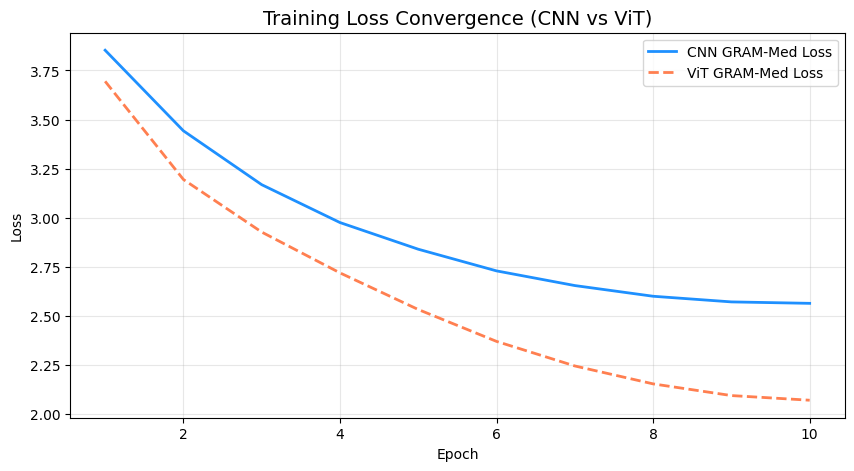

In [5]:
if loaded_successfully:
    plt.figure(figsize=(10, 5))
    plt.plot(cnn_epochs, [x["train_loss"] for x in cnn_hist], label="CNN GRAM-Med Loss", color='dodgerblue', linewidth=2)
    plt.plot(vit_epochs, [x["train_loss"] for x in vit_hist], label="ViT GRAM-Med Loss", color='coral', linewidth=2, linestyle='--')
    plt.title("Training Loss Convergence (CNN vs ViT)", fontsize=14)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

### 4.5 Exact Retrieval Performance (CNN vs ViT)
Comparison of the final Exact R@10 accuracy between CNN and ViT. Note that the CNN model struggles severely with exact retrieval compared to the ViT model.

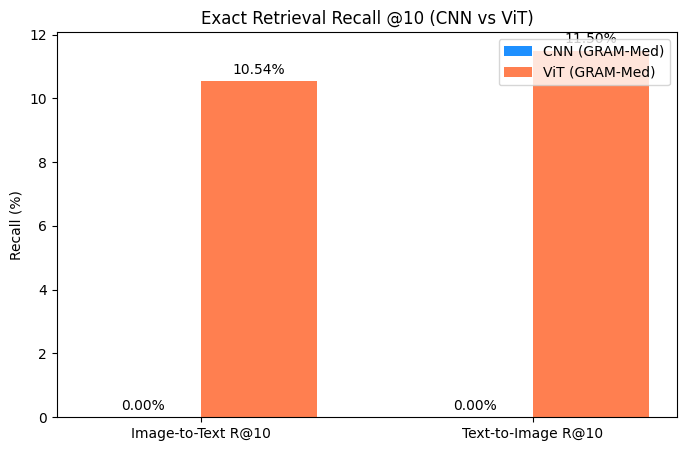

In [6]:
if loaded_successfully:
    labels = ['Image-to-Text R@10', 'Text-to-Image R@10']
    
    # Extract last epoch results
    cnn_results = [cnn_hist[-1]["i2t_R@10"] * 100, cnn_hist[-1]["t2i_R@10"] * 100]
    vit_results = [vit_hist[-1]["i2t_R@10"] * 100, vit_hist[-1]["t2i_R@10"] * 100]
    
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    rects1 = ax.bar(x - width/2, cnn_results, width, label='CNN (GRAM-Med)', color='dodgerblue')
    rects2 = ax.bar(x + width/2, vit_results, width, label='ViT (GRAM-Med)', color='coral')

    ax.set_ylabel('Recall (%)')
    ax.set_title('Exact Retrieval Recall @10 (CNN vs ViT)')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    
    # Annotate bars
    for rects in [rects1, rects2]:
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom')

    plt.show()

### 4.6 Escaping Representation Collapse (ViT)
This plot illustrates the phenomenon of representation collapse and the subsequent evasion for the ViT model.
In the early epochs, the Semantic Recall starts extremely high because the vision encoder projects all images into the exact same spatial neighborhood. As training progresses, the model semantically scatters the images across the latent space, dropping SemR to a physiological baseline while increasing the Exact Recall.

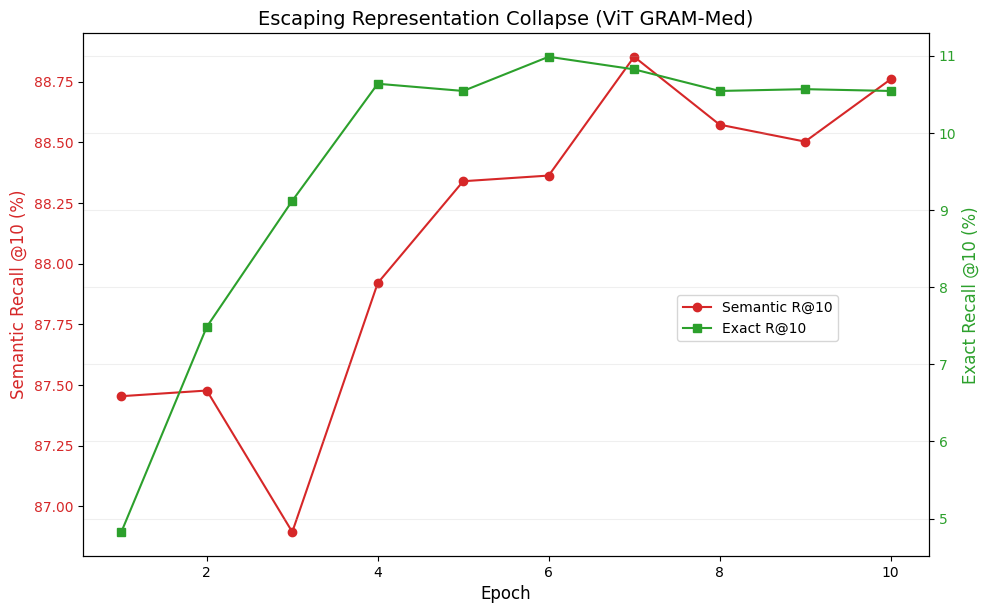

In [8]:
if loaded_successfully:
    fig, ax1 = plt.subplots(figsize=(10, 6))

    color = 'tab:red'
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Semantic Recall @10 (%)', color=color, fontsize=12)
    ax1.plot(vit_epochs, [x["i2t_SemR@10"] * 100 for x in vit_hist], color=color, label='Semantic R@10', marker='o')
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  
    color = 'tab:green'
    ax2.set_ylabel('Exact Recall @10 (%)', color=color, fontsize=12)  
    ax2.plot(vit_epochs, [x["i2t_R@10"] * 100 for x in vit_hist], color=color, label='Exact R@10', marker='s')
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()  
    plt.title("Escaping Representation Collapse (ViT GRAM-Med)", fontsize=14)
    fig.legend(loc="center right", bbox_to_anchor=(0.85, 0.5))
    plt.grid(True, alpha=0.2)
    plt.show()

## 🛑 5. Limitations and Reflections
- **Hardware Limitations**: This experiment required small batch sizes and the use of *Gradient Checkpointing* due to VRAM constraints. Training robust VLMs typically requires extensive GPU clusters to fully benefit from Contrastive Losses.
- **Architectural Constraints**: We observed how randomly initializing a CNN encoder (ResNet50) against a pre-trained textual transformer causes severe initial representation collapse. Our mathematical fallback (using the dot-product logic) allowed us to keep the topology intact without causing TypeErrors, waiting for the official volume-computation library integration.
- **Future Works**: Fully integrating GRAM's non-Euclidean volume computations (replacing the dot-product mockup) could further elevate the R@10 ceiling.

## 📚 6. References
1. **MedCLIP Paper**: Wang, Z., et al. "MedCLIP: Contrastive Learning from Unpaired Medical Images and Text." (2022).
2. **GRAM Framework**: Barbetta, F. et al. "Generative Representation Alignment for Medical domains." (GitHub Repository: [BarbettaFrancesco/medical-gram-clip](https://github.com/BarbettaFrancesco/medical-gram-clip)).
3. **Dataset**: [MIMIC-CXR Database](https://physionet.org/content/mimic-cxr/2.0.0/), PhysioNet.

## 🔁 7. Reproducibility Instructions
To reproduce our results locally or on a cloud environment:

1. **Clone the Repository**:
   ```bash
   git clone https://github.com/BarbettaFrancesco/medical-gram-clip.git
   cd medical-gram-clip
   ```
2. **Environment Setup (Linux/WSL recommended)**:
   ```bash
   python3 -m venv .venv
   source .venv/bin/activate
   pip install -r requirements.txt
   ```
3. **Set Environment Variables**:
   Create a `.env` file containing your personal Hugging Face token to access MIMIC-CXR:
   ```env
   HF_TOKEN=hf_YourPersonalTokenHere
   ```
4. **Launch the Training**:
   ```bash
   ./run_experiments.sh
   ```
> *Note for Colab*: It is sufficient to execute a `!git clone`, navigate to the folder, and run `./run_experiments.sh`, ensuring the Colab Runtime is set to GPU (T4/L4 or A100).